# Modelos de Regresion

La regresión es una herramienta que permite estimar la media condicional a una o más variables de una variable dependiente (Y) dado un conjunto de otras variables llamadas regresoras, variables condicionales o covariables (X).

$$E(Y|\mathbf{X}) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_k X_k + \varepsilon$$

* $E(Y|\mathbf{X})$ es el valor esperado de $Y$ dado el conjunto de covariables $\mathbf{X}$
* $\beta_k$ estima el cambio promedio esperado en $Y$ ante cambios en $X_k$
* $\beta_0$ es el intercepto de la regresión
* $\varepsilon$ errores de estimación

# Regresion lineal en Series de Tiempo

$$y_t = \beta_0 + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \cdots + \beta_k x_{k,t} + \epsilon_t$$

Aunque la fórmula sea la misma, los supuestos cambian drásticamente. En una regresión normal, asumimos que las observaciones son independientes. En series de tiempo, esto casi nunca es cierto debido a:

- Autocorrelación: Lo que pasó ayer suele influir en lo que pasa hoy. Si hay autocorrelación en los errores ($\epsilon_t$), los resultados de tu regresión lineal simple pueden ser engañosos.
- Estacionalidad: Patrones que se repiten (ej. las ventas suben siempre en diciembre).
- No estacionariedad: Si la media o la varianza de la serie cambian con el tiempo, la regresión lineal puede dar "correlaciones espurias" (parece que hay relación, pero es solo coincidencia temporal)

**Nota importante:** En series de tiempo, el orden de los datos no se puede alterar. Si barajas las filas (como harías en otros modelos de Machine Learning), pierdes toda la información de la estructura temporal

/tmp/ipykernel_62217/3772101029.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


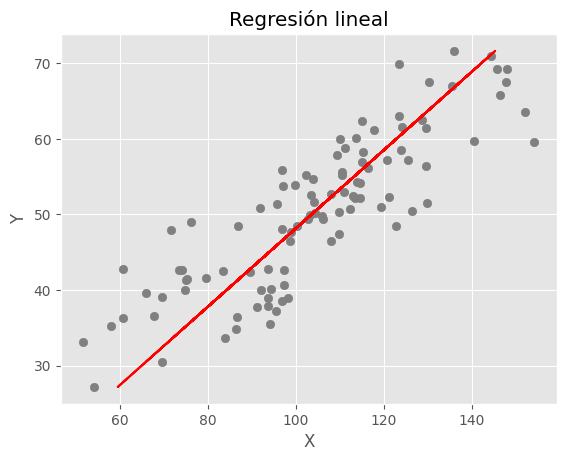

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

x = np.random.normal(50, 10, 100)
y = np.random.normal(2, 10, 100) + 2 * x + np.random.normal(0, 1, 100)
X = sm.add_constant(x)
lm = sm.OLS(y, X).fit()
y_hat = lm.predict()

plt.style.use('ggplot')
fig, ax = plt.subplots()
ax.scatter(y, x, color = "gray")
ax.plot(y_hat, x, color = "red")
plt.title('Regresión lineal')
plt.xlabel('X')
plt.ylabel('Y')
fig.show()

## Estimador de Minimos Cuadrados Ordinarios (MCO)

El estimador MCO permite buscar los coeficientes βk de una regresión tal que minimiza la suma de los errores (el valor más pequeño) de la regresión.

### Ecuaciones del Modelo de Regresión

1. **Definición del error (residuo):**
$$\epsilon_t = y_t - \hat{y}_t$$

2. **Modelo de regresión múltiple:**
$$\hat{y}_t = \beta_0 + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \cdots + \beta_k x_{k,t} + \epsilon_t$$

3. **Suma de los cuadrados de los residuos (Mínimos Cuadrados Ordinarios):**
$$\sum_{t=1}^{T} \epsilon_t^2 = \sum_{t=1}^{T} (y_t - \beta_0 - \beta_1 x_{1,t} - \beta_2 x_{2,t} - \cdots - \beta_k x_{k,t})^2$$

4. **Supuesto de normalidad de los errores:**
* Supuesto $\hat{\epsilon}_t \sim N(0, \sigma^2)$

## Comprobación Práctica de Mínimos Cuadrados Ordinarios (MCO)

Para entender cómo funciona la regresión en series de tiempo, utilizaremos un conjunto de datos simulado muy corto ($T=3$).

### 1. Datos de la Serie de Tiempo
| Tiempo ($t$) | Variable Independiente ($x_t$) | Variable Dependiente ($y_t$) |
| :--- | :--- | :--- |
| 1 | 1 | 3 |
| 2 | 2 | 4 |
| 3 | 3 | 6 |

**Coeficientes estimados (Asumidos):**
* $\hat{\beta}_0 = 1.33$
* $\hat{\beta}_1 = 1.5$

---

### 2. Proceso de Cálculo de Residuos

Utilizamos la fórmula de la recta estimada: $\hat{y}_t = \hat{\beta}_0 + \hat{\beta}_1 x_t$ y luego calculamos el error $\epsilon_t = y_t - \hat{y}_t$.

#### A. Valores Estimados ($\hat{y}_t$)
* $\hat{y}_1 = 1.33 + 1.5(1) = 2.83$
* $\hat{y}_2 = 1.33 + 1.5(2) = 4.33$
* $\hat{y}_3 = 1.33 + 1.5(3) = 5.83$

#### B. Cálculo de los Errores al Cuadrado ($\epsilon_t^2$)
Aplicamos la fórmula de la sumatoria que minimiza el modelo:

$$
\sum_{t=1}^{T} \epsilon_t^2 = \sum_{t=1}^{T} (y_t - \hat{y}_t)^2
$$

**Desarrollo paso a paso:**

$$
\begin{aligned}
\epsilon_1^2 &= (3 - 2.83)^2 = (0.17)^2 = 0.0289 \\
\epsilon_2^2 &= (4 - 4.33)^2 = (-0.33)^2 = 0.1089 \\
\epsilon_3^2 &= (6 - 5.83)^2 = (0.17)^2 = 0.0289 \\
\hline
\sum \epsilon_t^2 &= \mathbf{0.1667}
\end{aligned}
$$

---

### 3. Conclusión del Supuesto $\hat{\epsilon}_t \sim N(0, \sigma^2)$
En este ejercicio manual, observamos que:
1. La suma de los errores simples $\sum \epsilon_t$ es aproximadamente $0$ ($0.17 - 0.33 + 0.17 = 0.01$, la diferencia es por redondeo de decimales).
2. El valor de $0.1667$ representa la **variabilidad no explicada** por el modelo. Cuanto menor sea este número, mejor ajusta nuestra línea de regresión a los datos históricos.

---

# Demostración Matemática de los Estimadores MCO

El objetivo es minimizar la Función de Pérdida $L$, que es la Suma de los Cuadrados de los Residuos (SCR):

$$L(\beta_0, \beta_1) = \sum_{t=1}^{T} \epsilon_t^2 = \sum_{t=1}^{T} (y_t - \beta_0 - \beta_1 x_t)^2$$

### 1. Condiciones de Primer Orden (Derivadas Parciales)
Para hallar el mínimo, derivamos $L$ respecto a cada parámetro e igualamos a cero:

**Respecto a $\beta_0$:**
$$\frac{\partial L}{\partial \beta_0} = -2 \sum_{t=1}^{T} (y_t - \beta_0 - \beta_1 x_t) = 0$$

**Respecto a $\beta_1$:**
$$\frac{\partial L}{\partial \beta_1} = -2 \sum_{t=1}^{T} x_t (y_t - \beta_0 - \beta_1 x_t) = 0$$

---

### 2. Obtención de los Estimadores

#### A. Estimador del Intercepto ($\hat{\beta_0}$)
De la primera ecuación, dividimos por $-2$ y distribuimos la sumatoria:
$$\sum y_t - \sum \beta_0 - \beta_1 \sum x_t = 0$$
$$\sum y_t - T\beta_0 - \beta_1 \sum x_t = 0$$

Si dividimos todo entre $T$ (el número de periodos), obtenemos las medias ($\bar{y}$ y $\bar{x}$):
$$\bar{y} - \hat{\beta_0} - \hat{\beta_1} \bar{x} = 0 \implies \mathbf{\hat{\beta_0} = \bar{y} - \hat{\beta_1} \bar{x}}$$

#### B. Estimador de la Pendiente ($\hat{\beta_1}$)
Sustituyendo $\hat{\beta_0}$ en la segunda ecuación de las derivadas y despejando $\beta_1$, llegamos a la fórmula clásica:

$$\mathbf{\hat{\beta_1} = \frac{\sum_{t=1}^{T} (x_t - \bar{x})(y_t - \bar{y})}{\sum_{t=1}^{T} (x_t - \bar{x})^2}}$$

O en términos de covarianza y varianza:
$$\hat{\beta_1} = \frac{Cov(x, y)}{Var(x)}$$

### 2.2. El "Desmenuzado" de la Pendiente ($\hat{\beta}_1$)

Muchos textos saltan de la derivada a la fracción final. Aquí vemos paso a paso cómo llegamos a la relación entre covarianzas y varianzas.

#### Paso 1: Partimos de la segunda condición de primer orden
Después de derivar la Suma de Cuadrados de los Residuos (SCR) respecto a $\beta_1$ e igualar a cero, tenemos:
$$\sum_{t=1}^{T} x_t (y_t - \hat{\beta}_0 - \hat{\beta}_1 x_t) = 0$$

#### Paso 2: Sustitución del Intercepto ($\hat{\beta}_0$)
Sabemos por la primera derivada que $\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$. Al sustituirlo en la ecuación de arriba:
$$\sum x_t [y_t - (\bar{y} - \hat{\beta}_1 \bar{x}) - \hat{\beta}_1 x_t] = 0$$

Agrupamos los términos que tienen $\hat{\beta}_1$:
$$\sum x_t [(y_t - \bar{y}) - \hat{\beta}_1 (x_t - \bar{x})] = 0$$

#### Paso 3: Distribución de la sumatoria
Separamos la ecuación en dos sumatorias:
$$\sum x_t (y_t - \bar{y}) = \hat{\beta}_1 \sum x_t (x_t - \bar{x})$$

#### Paso 4: El truco de las desviaciones medias
Aquí aplicamos una propiedad fundamental de las sumatorias: $\sum x_t (y_t - \bar{y})$ es equivalente a $\sum (x_t - \bar{x})(y_t - \bar{y})$. 
*Esto sucede porque la suma de las desviaciones respecto a la media es cero.*

Aplicando esto a ambos lados:
$$\sum (x_t - \bar{x})(y_t - \bar{y}) = \hat{\beta}_1 \sum (x_t - \bar{x})^2$$

#### Paso 5: Despeje Final
Finalmente, pasamos el término de la derecha dividiendo para obtener la fórmula clásica de la pendiente:

$$\mathbf{\hat{\beta_1} = \frac{\sum_{t=1}^{T} (x_t - \bar{x})(y_t - \bar{y})}{\sum_{t=1}^{T} (x_t - \bar{x})^2}}$$

---
## Propiedades del MCO

Bajo el supuesto de que los errores siguen una distribución normal con media cero y varianza constante ($\epsilon \sim N(0, \sigma^2_\epsilon)$), los estimadores poseen las siguientes propiedades:

* **Insesgadez:** En promedio, el valor estimado es igual al valor real del parámetro.
    $$E(\hat{\beta}_k) = \beta_k$$
    
* **Varianza Mínima (Eficiencia):** Son los estimadores más precisos dentro de la clase de estimadores lineales. Sus varianzas se calculan como:
    $$Var(\hat{\beta}_0) = \frac{\sigma^2 \sum X_i^2}{n \sum(X_i - \bar{X})^2} \quad , \quad Var(\hat{\beta}_1) = \frac{\sigma^2}{\sum(X_i - \bar{X})^2}$$

* **Consistencia:** A medida que el tamaño de la muestra ($n$) aumenta indefinidamente, los estimadores convergen hacia sus verdaderos valores poblacionales.

---
## Significancia de los parametros (MCO)

Los parametros dados por el MCO se verifican a traves de una prueba de hipotesis

$$ H_0 : \beta_j = 0 $$
$$ H_a : \beta_j \neq 0 $$

Estadístico de prueba (t-student):
$$ t_{1-\alpha/2; (n-k)} = \frac{\beta_j - \hat{\beta}_j}{\sqrt{Var(\hat{\beta}_j)}} $$

Si el p_value nos da **p_value < 0.05** eso quiere decir que hay suficiente evidencia estadistica para rechazar la $H_0$ lo cual quiere decir que seria diferente a 0, es decir, **significante**

---

## Evaluando el MCO

Despues de seleccionar las variables de Regresion y ajustar el modelo, en lo que hay que fijarse es en los residuos, para ver que **los supuestos se cumplieron**. Graficamente no podemos ver un patron funcional entre los errores y los valores predichos del modelo ya que eso quiere decir que parte la informacion que tuvo que haber absorbida por las variable so parametros esta siendo absorbida por los errores



# Laboratorio de Regresion

Ejercicio: Modelo de Factores de Emisión de Benceno ($C_6H_6$). Queremos modelar la concentración de un contaminante basado en otros indicadores ambientales medidos simultáneamente.

Dataset: **Air Quality Data Set** (https://www.google.com/search?q=https://archive.ics.uci.edu/dataset/165/air%2Bquality)

Variables que usaremos:
- $Y_t$: Concentración de Benceno ($C_6H_6(GT)$).
- $X_{1t}$: Óxidos de Nitrógeno ($NOx(GT)$).
- $X_{2t}$: Dióxido de Nitrógeno ($NO_2(GT)$).
- $X_{3t}$: Temperatura ($T$).
- $X_{4t}$: Humedad Relativa ($RH$).2. 

**Modelo a Estimar**

Debes ajustar una regresión múltiple con la siguiente estructura (idéntica a la de tu imagen):$$C_6H_6t = \beta_0 + \beta_1 NOx_t + \beta_2 NO2_t + \beta_3 Temp_t + \beta_4 Humedad_t + \epsilon_t$$




## 1. Carga & Limpieza

In [2]:
import pandas as pd
import statsmodels.api as sm

# Configuración visual
plt.style.use('ggplot')
%matplotlib inline

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  

df = air_quality.data.features 

In [4]:
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2004-03-10,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2004-03-10,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2004-03-10,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,2004-03-10,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


Elegimos Features que usaremos

$$C_6H_6t = \beta_0 + \beta_1 NOx_t + \beta_2 NO2_t + \beta_3 Temp_t + \beta_4 Humedad_t + \epsilon_t$$

In [6]:
df = df[["Date","C6H6(GT)","NOx(GT)","NO2(GT)","T","RH"]] #Eligiendo features a usar
df.head(5)

,Date,C6H6(GT),NOx(GT),NO2(GT),T,RH
0,2004-03-10,11.9,166,113,13.6,48.9
1,2004-03-10,9.4,103,92,13.3,47.7
2,2004-03-10,9.0,131,114,11.9,54.0
3,2004-03-10,9.2,172,122,11.0,60.0
4,2004-03-10,6.5,131,116,11.2,59.6


In [7]:
df_clean = df.copy()
columnas = ["C6H6(GT)","NOx(GT)","NO2(GT)","T","RH"]
df_clean[columnas] = df_clean[columnas].replace(-200, np.nan)

In [8]:
# Para series de tiempo, lo ideal es interpolar los huecos para no perder la secuencia
df_clean = df_clean.interpolate(method='linear').dropna()

## 2. Visualizacion de Series de Tiempo

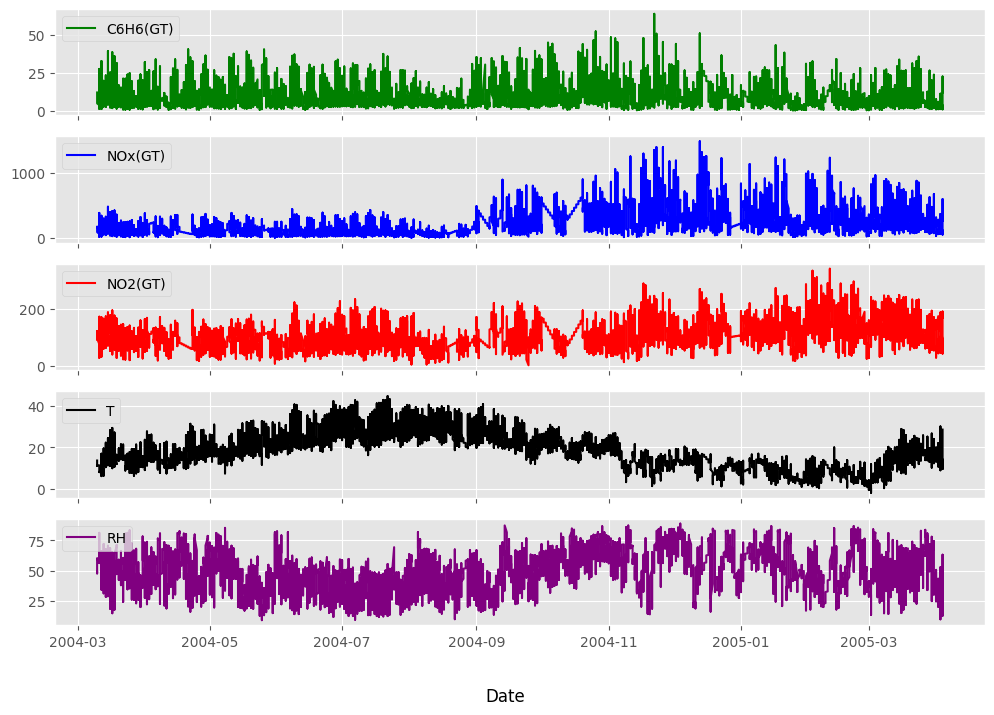

In [9]:
colores = ["green","blue","red","black","purple"]

fig,axes = plt.subplots(nrows=len(columnas),ncols=1,sharex=True,figsize=(12,8))
for i, variable in enumerate(columnas):
    axes[i].plot(df_clean["Date"],df_clean[variable],label=variable,color=colores[i])
    axes[i].legend(loc="upper left")

fig.supxlabel("Date")
plt.show()

## 3. Correlacion y Exploracion de Variables

Ahora realizamos un grafico de correlacion exploratorio

<Axes: >

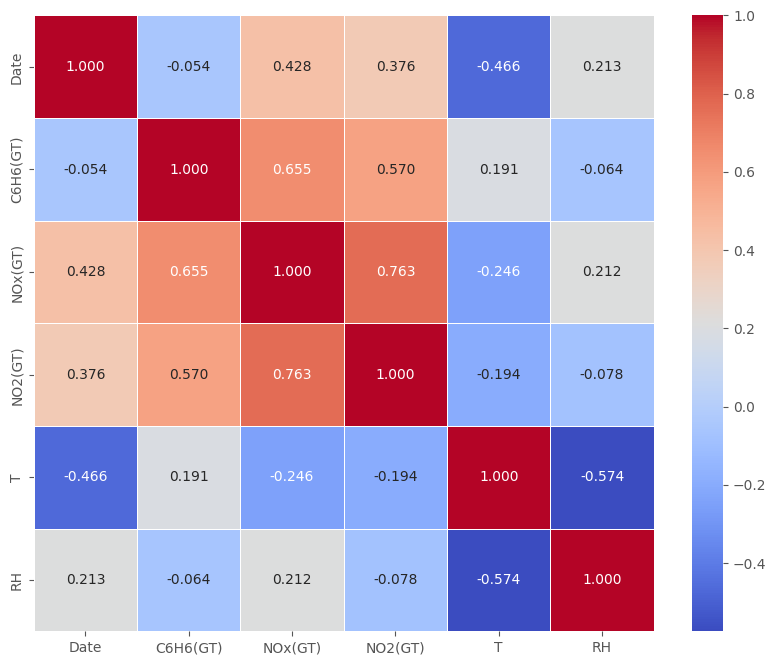

In [10]:
import seaborn as sns

plt.figure(figsize=(10, 8))

# Calculamos la matriz de correlación
corr = df_clean.corr()

# Dibujamos el mapa de calor
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)

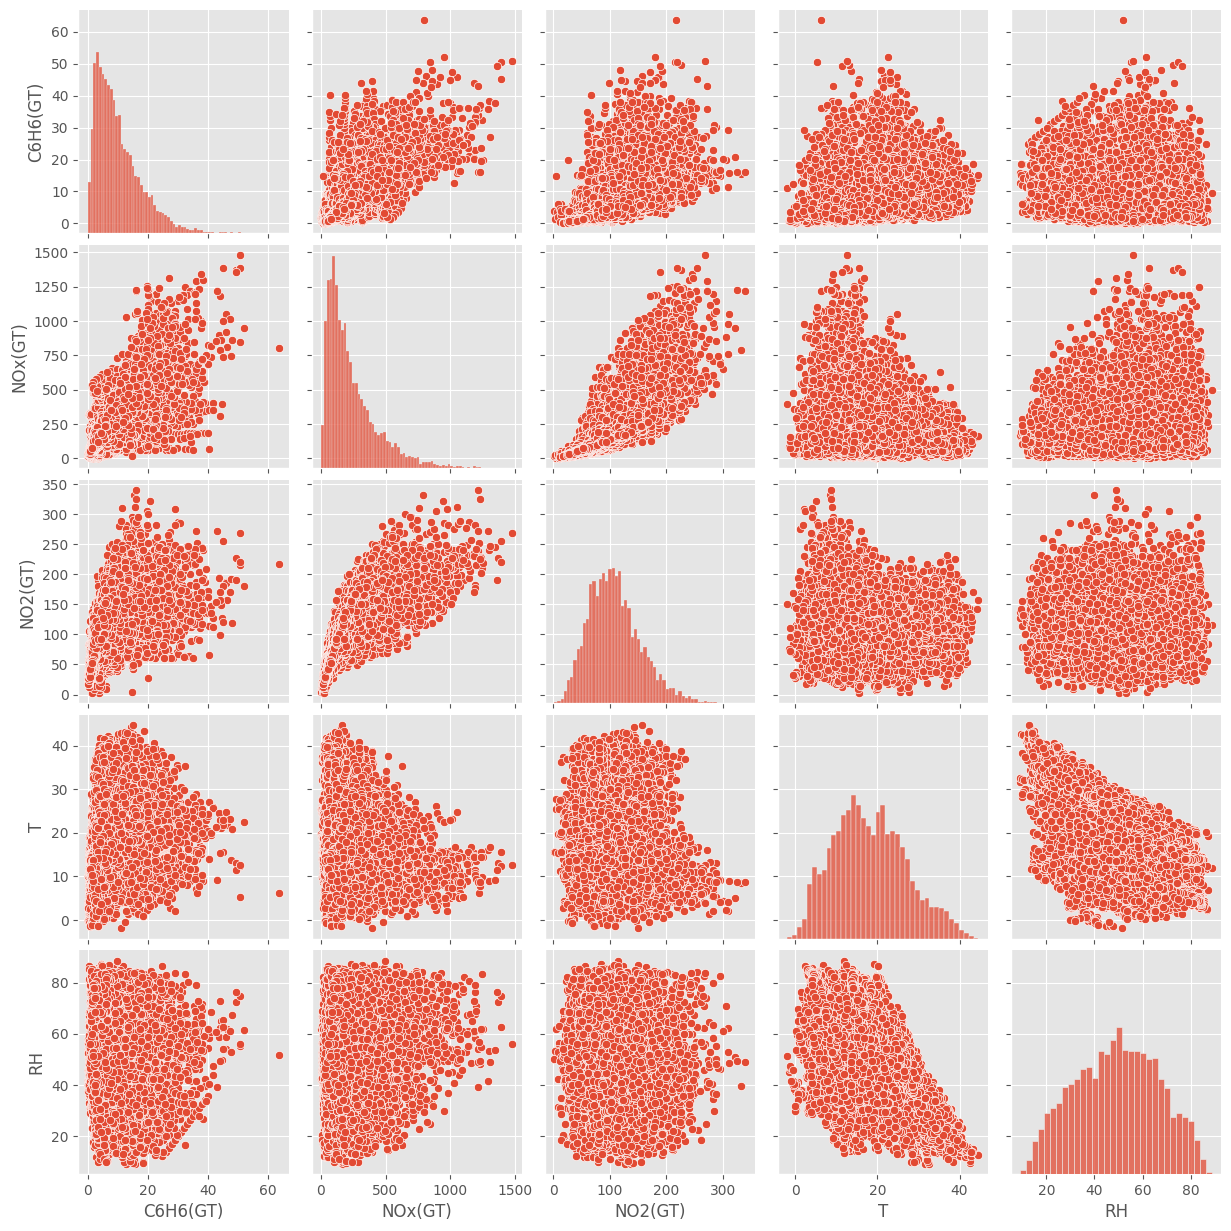

In [11]:
sns.pairplot(df_clean)

## 4. Modelo Regresion Lineal

Ahora realizamos el modelo de **Regresion Lineal por MCO**

In [12]:
y = df_clean[["C6H6(GT)"]]
X = df_clean[["NOx(GT)","NO2(GT)","T","RH"]]

X = sm.add_constant(X)
ml = sm.OLS(y,X).fit()
ml.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               C6H6(GT)   R-squared:                       0.576
Model:                            OLS   Adj. R-squared:                  0.576
Method:                 Least Squares   F-statistic:                     3176.
Date:                Sat, 28 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:53:07   Log-Likelihood:                -28120.
No. Observations:                9357   AIC:                         5.625e+04
Df Residuals:                    9352   BIC:                         5.629e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.6659      0.383    -17.426      0.000      -7.416      -5.916
NOx(GT)        0.0213      0.000     49.938      0.000       0.020       0.022
NO2(GT)        0.0346      0.002     18.232      0.000       0.031       0.038
T              0.3537      0.007     47.651      0.000       0.339       0.368
RH             0.0297      0.004      7.301      0.000       0.022       0.038
==============================================================================
Omnibus:                     3006.481   Durbin-Watson:                   0.423
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15340.680
Skew:                           1.464   Prob(JB):                         0.00
Kurtosis:                       8.548   Cond. No.                     2.55e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.55e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 5. Interpretacion del modelo

### **Bondad de ajuste**

- El modelo explica el 57.6% de la variabilidad del Benceno. Para ser datos ambientales de series de tiempo con mucha volatilidad (como viste en tus gráficas), es un ajuste aceptable, aunque indica que hay otros factores (viento, tráfico, etc.) que no estamos midiendo.

- Adj. R-squared (0.576): Al ser igual al R-cuadrado, confirma que todas las variables incluidas están aportando valor y no hay "ruido" excesivo por exceso de variables.

### **Coeficientes**

- Todas las variables ($NOx, NO2, T, RH$) son estadísticamente significativas con un nivel de confianza superior al 99% Por el p_value.
- Temperatura (T) [0.3537]: Es la variable con mayor impacto positivo. Por cada grado Celsius que sube la temperatura, el nivel de benceno tiende a subir 0.35 unidades.
- NO2(GT) [0.0346]: Tiene un impacto positivo; a mayor presencia de este gas, mayor es la concentración de benceno.


## 6. Verificacion de Linealidad y/o Supuestos

### Linealidad

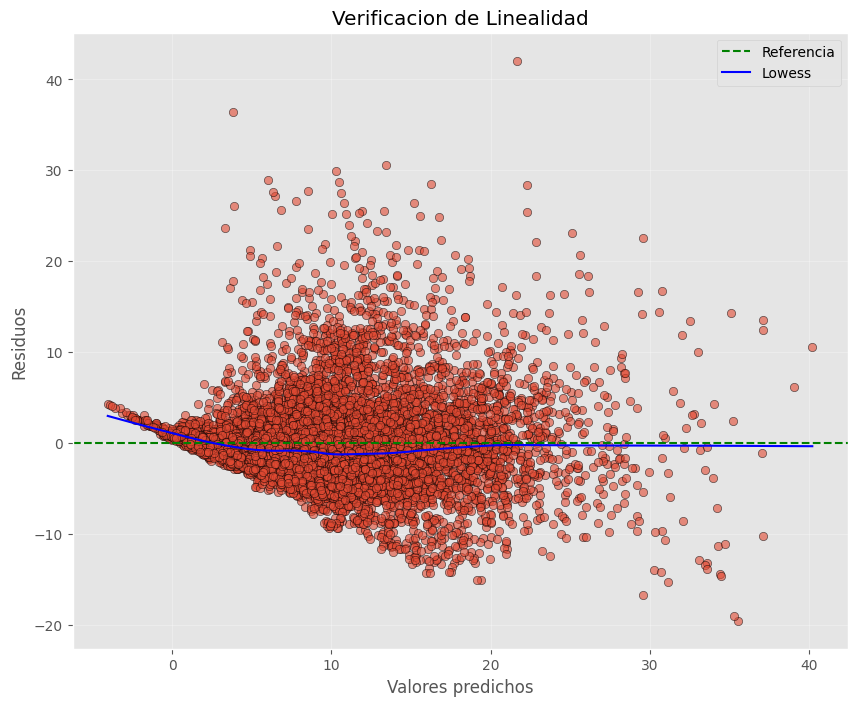

In [13]:
from statsmodels.nonparametric.smoothers_lowess import lowess

resid = ml.resid
fitted_values = ml.fittedvalues

plt.figure(figsize=(10,8))
#Dispersion de los valores predichos y residuos
plt.scatter(fitted_values,resid,alpha=0.6,edgecolors="k",linewidths=0.5)

# lineas de referencia y Tendencia
plt.axhline(y=0,color="green",linestyle="--",label="Referencia")
smooth = lowess(resid,fitted_values,frac=0.3)
plt.plot(smooth[:,0],smooth[:,1],color="blue",label="Lowess")

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Verificacion de Linealidad")
plt.legend()
plt.grid(True,alpha=0.3)

La **Interpretacion** del grafico es:

1. Linealidad: Como vemos la curva **lowess** no esta completamente pegada a la y=0, ya que al estar cerca de 0 toma una curva hacia arriba los errores y se ve asimetrica la distribucion de puntos antes del 0 lo que nos da a entender que el modelo quizas tiene alguna tendencia, relacion no lineal que no está captando el modelo ya sea logaritmica o cuadratica

2. Homocedasticidad: Vemos como cerca del valor predicho **0**, los puntos se agrupan estruendosamente y mientras mas grande se vuelve el valor predicho (10,20,30...) la **dispersion** es cada vez mas grande lo que nos da a entender que existe **Heterocedasticidad** en forma de embudo. La **varianza del error** aumenta conforme con el valor predicho, esto es un problema para los intervalos de confianza y los p_values invalidandolos

### Distribucion de los errores

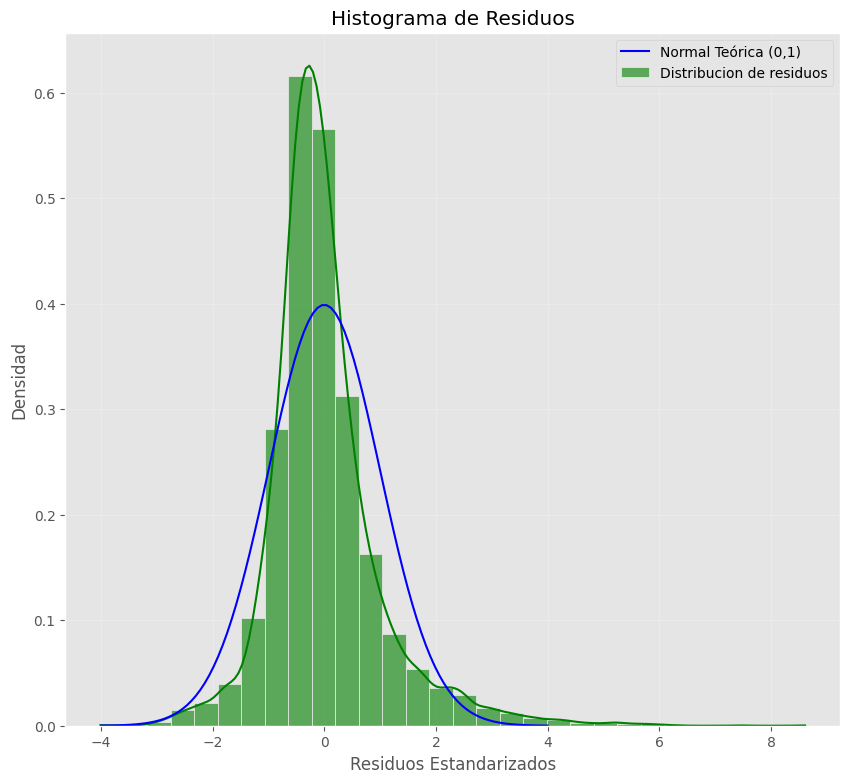

In [14]:
from scipy import stats

#Residuos Estandarizados
resid = ml.resid
resid_std = (resid - resid.mean()) / resid.std()

plt.figure(figsize=(10,9))

#Histograma de Residuos Estandarizados
sns.histplot(resid_std, bins=30, kde=True, stat="density", alpha=0.6, color="green",label="Distribucion de residuos")

#Distribucion Normal Teorica
x = np.linspace(-4, 4, 100)
plt.plot(x, stats.norm.pdf(x, 0, 1), color='Blue', label='Normal Teórica (0,1)')

plt.xlabel("Residuos Estandarizados")
plt.ylabel("Densidad")
plt.title("Histograma de Residuos")
plt.grid(True,alpha=0.2)
plt.legend()

Lo que nos da a entender esta grafica es:

1. La **leptocurtosis** de nuestros residuos indica que el modelo al tener esa distribucion tan empinada no esta siguiendo una distrobucion normal

2. Ademas vemos que hay un **skew** positivo que llega hasta mas de 8, mientras en la teorica hasta 4 lo que nos da a entender precisamente que hay muchos outliers que no se ven en el modelo, es decir, lo que da a entender es que hay datos que no tienen varianza contante que son muy volatiles, es no decir **Varianza NO constante** 

3.  Y como estas 2 cosas estan mal, por tanto los p_values ya no son una buena medida de confiabilidad, ya que la verde no se ajusta a la azul

### Q-Q Plot

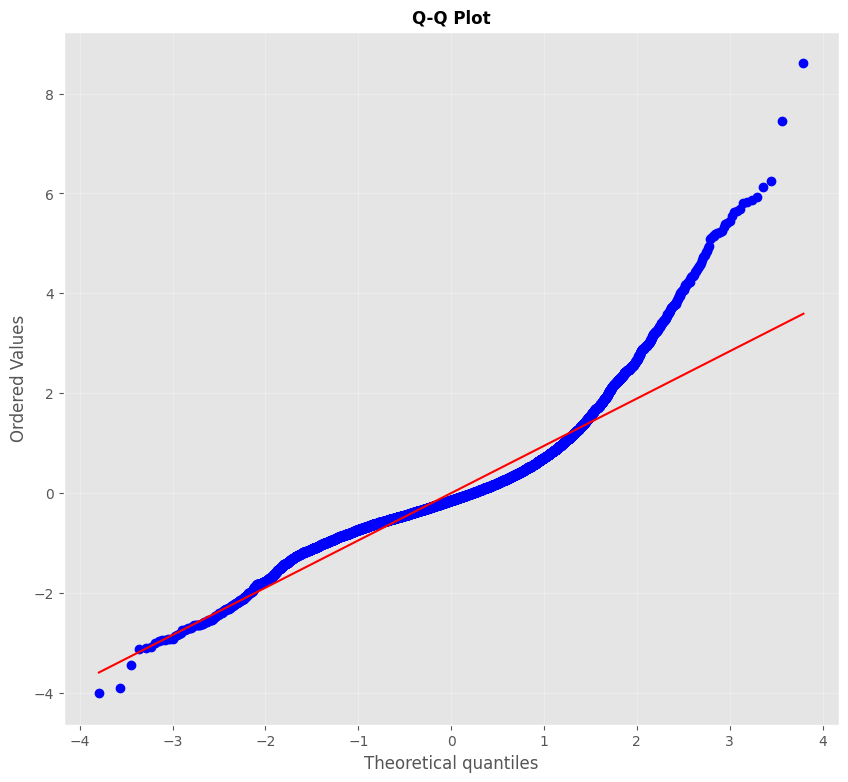

In [15]:
plt.figure(figsize=(10,9))

stats.probplot(resid_std, dist="norm",plot=plt)
plt.title('Q-Q Plot', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

¿Que podemos interpretar?

Vemos que hay un **skew** positivo muy grande ya que la cola derecha que salia en la Distribucion de los errores es la misma que esta saliendo en el Q-Q Plot lo que nos da a entender mas aun que efectivamente el modelo está **subestimando** los valores mas altos de la serie, y esos puntos son los mismos **outliers**  que salian de la distribucion

### Pruebas de normalidad

In [16]:
from statsmodels.stats.stattools import jarque_bera

# Prueba de Shapiro-Wilk
shapiro_stat, shapiro_p = stats.shapiro(resid)
    
# Prueba de Jarque-Bera
jb_stat, jb_p, skew, kurtosis = jarque_bera(resid)
    
# Prueba de Kolmogorov-Smirnov
ks_stat, ks_p = stats.kstest(resid_std, 'norm')

results = {
        'test' : ['Shapiro-Wilk', 'Jarque-Bera', 'Kolmogorov-Smirnov', 'Asimetría', 'Curtosis'],
        'estadistico' : [shapiro_stat, jb_stat, ks_stat, skew, kurtosis],
        'p_valor' : [shapiro_p, jb_p, ks_p, None, None]
    }

tab_test = pd.DataFrame(results)
tab_test

/mnt/c/Users/Pc/Documents/series-de-tiempo-utb/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9357.
  res = hypotest_fun_out(*samples, **kwds)


,test,estadistico,p_valor
0,Shapiro-Wilk,0.896169,9.042683e-62
1,Jarque-Bera,15340.680324,0.000000e+00
2,Kolmogorov-Smirnov,0.115065,2.216487e-108
3,Asimetría,1.463511,NaN
4,Curtosis,8.547994,NaN


Lo que nos da a entender que efectivamente no hay normalidad, los p_values dieron mucho menor a 0.05 rechazando la hipotesis de que son normales

### Residuos Correlacionados?

Text(0.5, 1.0, 'Residuos del modelo')

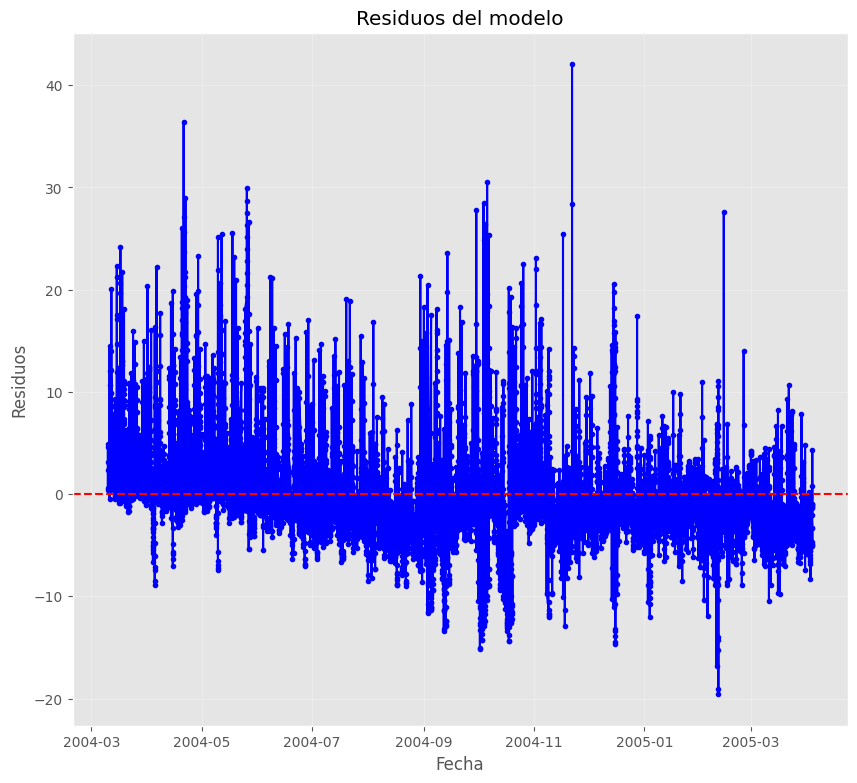

In [21]:
# Gráfico de Residuos
plt.figure(figsize=(10,9))
plt.plot(df_clean["Date"],resid,color="blue",label="residuos",marker=".")
plt.axhline(0,color="red",linestyle="--",label="y=0")
plt.grid(True,alpha=0.3)
plt.xlabel("Fecha")
plt.ylabel("Residuos")
plt.title("Residuos del modelo")


Text(0.5, 1.0, 'ACF')

<Figure size 1000x900 with 0 Axes>

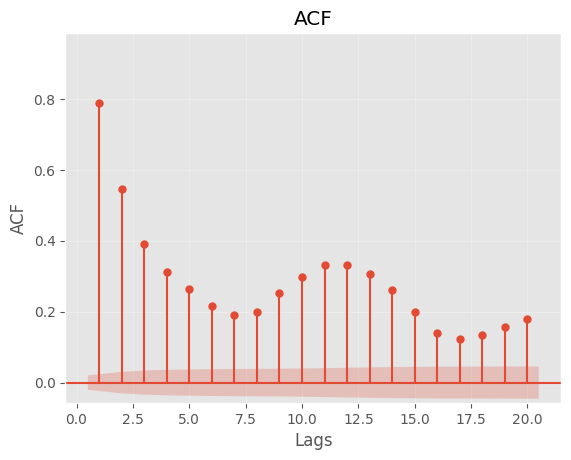

In [ ]:
#ACF
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.figure(figsize=(10,9))

plot_acf(resid,zero=False,lags=20,auto_ylims=True)
plt.grid(True,alpha=0.3)
plt.ylabel("ACF")
plt.xlabel("Lags")
plt.title("ACF")

In [30]:
ljung = acorr_ljungbox(resid,lags=20,return_df=True)
ljung, ljung.mean()

(         lb_stat  lb_pvalue
 1    5817.057520        0.0
 2    8608.759755        0.0
 3   10046.426387        0.0
 4   10964.798534        0.0
 5   11613.236317        0.0
 6   12054.650374        0.0
 7   12396.475871        0.0
 8   12772.436239        0.0
 9   13365.485444        0.0
 10  14202.089550        0.0
 11  15226.486653        0.0
 12  16254.391358        0.0
 13  17131.200955        0.0
 14  17776.061331        0.0
 15  18145.348202        0.0
 16  18327.454537        0.0
 17  18466.969164        0.0
 18  18636.633140        0.0
 19  18867.979300        0.0
 20  19168.003275        0.0,
 lb_stat      14492.097195
 lb_pvalue        0.000000
 dtype: float64)

Conclusiones de la Autocorrelacion en los residuos

1. La serie temporal de los residuos se ve que la altura de esos puntos cambia drasticamente a medida que pasa el tiempo y hay "shocks" o eventos muy extremos, lo que nos dice que hay **Heterocedasticidad** 

2. El grafico **ACF** nos muestra que casi todas las barras de los lags estan por encima del Intervalo de confianza o la franja lo que nos dice que Existe autocorrelacion Serial Significativa, es decir, los residuos no son Independientes, por lo que nos da a entender que el modelo no está captando eso y queda en los errores

3. La prueba **Ljung-Box** Nos confirma que dado los p_values y la media de estos en los 20 lags hechos nos dice que **rechazamos la H0** de que los residuos son solo **ruido blanco** es decir N(0,1) no se cumple

Es decir en Cocnlusion este modelo de Regresion Lineal actual es **INVALIDO** para realizar inferencias confiables. Los residuos muestran que no se cumplen los supuestos de normalidad, varianza constante e Independencia.